# House Price Prediction — Model Notebook

This notebook builds the regression model used by the house-price web app: load listing data, clean and engineer features, explore patterns, train models, and export artifacts.

**Dataset:** `data/house_prices.csv` — Indian property listings (~187k rows, 21 raw columns)

**Target variable:** `price_clean` — sale price in rupees, parsed from `Amount(in rupees)`

---

## Notebook sections

1. **Initial inspection** — shape, dtypes, missing values
2. **Cleaning & feature engineering** — parse text fields, impute, group categoricals, drop outliers
3. **Exploratory analysis** — key plots on cleaned data
4. **Model pipeline** — preprocessing + train three regressors
5. **Evaluation** — compare metrics, predicted vs actual, cross-validation
6. **Export** — save `house_price.pkl` and `locations.json` for the backend/frontend



## 2.1 — Initial Inspection

Before any cleaning, we load the CSV and inspect structure, data types, summary statistics, and missing values.

The code cells below run, in order:

- **`df.shape`** — row and column count
- **`df.head()`** — sample rows
- **`df.info()`** — dtypes and non-null counts per column
- **`df.describe()`** — numeric summaries
- **Missing-value rates** — sorted share of NaNs per column
- **`Carpet Area` / `Floor` value counts** — inspect messy text formats before parsing



In [44]:
import os
import zipfile

csv_path = "data/house_prices.csv"
zip_path = "data/house_prices.zip"

# فك الضغط فقط إذا لم يكن ملف الـ CSV موجوداً بالفعل
if not os.path.exists(csv_path):
    if os.path.exists(zip_path):
        print("📦 Extracting dataset from house_prices.zip...")
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall("data")
        print("✅ Extraction complete!")
    else:
        print("⚠️ Warning: Neither CSV nor ZIP file found in data/ directory.")
else:
    print("⚡ house_prices.csv already exists. Skipping extraction.")

⚡ house_prices.csv already exists. Skipping extraction.


> **On repo size:** don't commit the raw CSV or a zipped copy of it — GitHub isn't meant to store datasets, and it's what caused the push failures. Add `data/` (and `*.csv`, `*.zip`) to `.gitignore`, and instead document the two-line Kaggle CLI download command in the README (see Phase 1) so anyone who clones the repo can fetch the data themselves. Keep the auto-extract cell above only as a *local convenience* if a zip happens to be sitting in `data/` — it's not a substitute for `.gitignore`.
>
> For `house_price.pkl` (the trained model, not the dataset): it's fine to commit *if* it stays under ~50MB. The export cell at the end compresses it with `joblib` and prints the final file size so you can check — if it's still too big, either trim `n_estimators`/`max_depth` on the Random Forest, or track it with Git LFS (`git lfs track "*.pkl"`) instead of committing it raw.

In [45]:
import pandas as pd
import numpy as np


df = pd.read_csv("data/house_prices.csv")

df.shape

(187531, 21)

In [46]:
df.head()


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [47]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [48]:
df.describe()


,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [49]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

In [50]:
df["Carpet Area"].value_counts().head(20)

Carpet Area
1000 sqft    5285
900 sqft     4649
1300 sqft    3457
1600 sqft    2752
600 sqft     2225
1500 sqft    2151
950 sqft     1940
1250 sqft    1675
850 sqft     1674
400 sqft     1657
1700 sqft    1556
1400 sqft    1513
700 sqft     1392
1050 sqft    1384
750 sqft     1345
1200 sqft    1323
1450 sqft    1305
1350 sqft    1299
1100 sqft    1141
1800 sqft    1112
Name: count, dtype: int64

In [51]:
df["Floor"].value_counts().head(20)

Floor
2 out of 4          12433
1 out of 4          11985
3 out of 4           8792
1 out of 3           7093
4 out of 4           6253
2 out of 3           6016
3 out of 3           4796
2 out of 5           4741
Ground out of 4      4348
4 out of 5           3831
3 out of 5           3762
3 out of 6           3634
2 out of 2           3441
1 out of 5           3390
5 out of 5           3119
1 out of 2           2887
8 out of 10          2386
Ground out of 10     2157
3 out of 10          1972
4 out of 8           1899
Name: count, dtype: int64

### Findings

Summary of what the inspection cells above show:

- **Size:** 187,531 listings, 21 columns before cleaning.
- **Numeric columns:** `Index`, `Price (in rupees)`, `Bathroom`, `Balcony`, `Car Parking` (numeric-like but stored as text with missing values), `Dimensions` / `Plot Area` (100% missing — unusable).
- **Text / categorical columns:** `Title`, `Description`, `Amount(in rupees)`, `location`, `Carpet Area`, `Status`, `Floor`, `Transaction`, `Furnishing`, `facing`, `overlooking`, `Society`, `Ownership`, `Super Area`.
- **Heaviest missingness:** `Plot Area` and `Dimensions` (100%, dropped). Also high missingness in `Society` (~58%), `Super Area` (~57%), `Car Parking` (~55%), `overlooking` (~43%), `Carpet Area` (~43%), and `facing` (~37%) — handled below via fallback columns, grouping, or imputation.



## 2.2 — Cleaning & Feature Engineering

Raw columns mix units and formats (e.g. `"1.20 Cr"`, `"1000 sqft"`, `"3 out of 10"`). We parse them into numeric features **before** EDA so plots and models use consistent values.

### Target — `Amount(in rupees)` → `price_clean`

Values look like `"42 Lac"`, `"1.20 Cr"`, or plain numbers. Conversions: 1 Lac = ₹100,000 · 1 Cr = ₹10,000,000. Rows that cannot be parsed (e.g. `"Call for Price"`) are dropped — they carry no usable target.



In [52]:
def parse_amount(x):
    """Parse strings like '42 Lac', '1.20 Cr', 'Call for Price' into a rupee float."""
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
print("Unparseable / missing prices:", df["price_clean"].isna().sum())

df = df.dropna(subset=["price_clean"]).copy()
print("Shape after dropping rows with unusable price:", df.shape)

Unparseable / missing prices: 9684
Shape after dropping rows with unusable price: (177847, 22)


### Area — `Carpet Area` / `Super Area` → `carpet_area_sqft`

Values look like `"1000 sqft"`, `"140 sqm"`, `"1,200 sq. yards"`. All units are normalized to sqft (1 sqm ≈ 10.764 sqft · 1 sq yard = 9 sqft). Because `Carpet Area` alone is ~43% missing, we fall back to `Super Area` when needed.



In [53]:
import re

def parse_area(x):
    """Parse strings like '1000 sqft', '140 sqm', '1,200 sq. yards' into a sqft float."""
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower().replace(",", "")
    m = re.search(r"([\d.]+)\s*(sqft|sq\.?\s*ft|sqm|sq\.?\s*m|sq\.?\s*yards?|sq\.?\s*yd)?", x)
    if not m:
        return np.nan
    try:
        value = float(m.group(1))
    except ValueError:
        return np.nan
    unit = (m.group(2) or "sqft").replace(".", "").replace(" ", "")
    if "sqm" in unit:
        return value * 10.764
    if "yard" in unit or "yd" in unit:
        return value * 9.0
    return value  # default: already sqft

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
super_area_sqft = df["Super Area"].apply(parse_area)
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(super_area_sqft)

print("Missing carpet_area_sqft after Carpet+Super fallback:", round(df["carpet_area_sqft"].isna().mean(), 3))

Missing carpet_area_sqft after Carpet+Super fallback: 0.001


### Floor — `Floor` → `floor_num`

Values look like `"3 out of 10"`, `"Ground out of 4"`, `"Basement out of 2"`. Mapping: Ground → 0 · Basement → -1 · otherwise extract the leading number.



In [54]:
def parse_floor(x):
    """Parse strings like '3 out of 10', 'Ground out of 4', 'Basement out of 2' into a numeric floor."""
    if not isinstance(x, str):
        return np.nan
    x = x.strip().lower()
    floor_part = x.split("out of")[0].strip()
    if "ground" in floor_part:
        return 0
    if "basement" in floor_part or "lower" in floor_part:
        return -1
    m = re.search(r"(\d+)", floor_part)
    if m:
        return int(m.group(1))
    return np.nan

df["floor_num"] = df["Floor"].apply(parse_floor)
print("Missing floor_num:", round(df["floor_num"].isna().mean(), 3))

Missing floor_num: 0.039


### Amenities — `Bathroom`, `Balcony`, `Car Parking`

Converted to numeric. `bathroom` is imputed with the median; `balcony` and `car_parking` with 0 (absence is a reasonable default).



In [55]:
df["bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")
df["balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")

# "Car Parking" is text like "1 Covered", "2 Open", not a plain number —
# pd.to_numeric alone would coerce ALL of it to NaN (this was silently zeroing
# the column before). Extract the leading digit instead.
def parse_car_parking(x):
    if not isinstance(x, str):
        return 0
    m = re.search(r"(\d+)", x)
    return int(m.group(1)) if m else 0

df["car_parking"] = df["Car Parking"].apply(parse_car_parking)

df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())
df["balcony"] = df["balcony"].fillna(0)
# car_parking has no NaNs left (parse_car_parking already returns 0 for missing/unparseable)

df[["bathroom", "balcony", "car_parking"]].describe()

,bathroom,balcony,car_parking
count,177847.000000,177847.000000,177847.000000
mean,2.446103,1.478366,1.845946
std,0.850811,1.205886,21.550934
min,1.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000
75%,3.000000,2.000000,1.000000
max,10.000000,10.000000,999.000000


### High-cardinality categoricals — `location` and `Society`

Both have thousands of unique values. Keep the top 50 most frequent; group the rest as `"other"` to keep one-hot encoding manageable while retaining signal from common areas.



In [56]:
TOP_N = 50

top_locations = df["location"].value_counts().head(TOP_N).index
df["location_grouped"] = np.where(df["location"].isin(top_locations), df["location"], "other")

top_societies = df["Society"].value_counts().head(TOP_N).index
df["society_grouped"] = np.where(df["Society"].fillna("other").isin(top_societies), df["Society"].fillna("other"), "other")

print("Unique locations kept (incl. 'other'):", df["location_grouped"].nunique())
df["location_grouped"].value_counts().head(10)

Unique locations kept (incl. 'other'): 51


location_grouped
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
Name: count, dtype: int64

### Drop unused / redundant columns

Remove IDs, free text, 100% missing columns, and raw columns replaced by cleaned versions (`Amount(in rupees)`, `Carpet Area`, `Floor`, etc.). `overlooking` is also dropped — heavily missing and not used as a model feature.



In [57]:
DROP_COLS = [
    "Index", "Title", "Description", "Dimensions", "Plot Area",
    "Amount(in rupees)", "Price (in rupees)", "Carpet Area", "Super Area",
    "Floor", "Bathroom", "Balcony", "Car Parking", "location", "Society",
    "overlooking",
]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
df.shape

(177847, 13)

### Outlier removal

Compute price-per-sqft and drop listings below the 1st or above the 99th percentile — typically data-entry errors or extreme listings that would distort the model.



In [58]:
df = df[df["carpet_area_sqft"] > 0].copy()
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]

low, high = df["price_per_sqft"].quantile([0.01, 0.99])
before = df.shape[0]
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)].copy()
print(f"Dropped {before - df.shape[0]} outlier rows (price/sqft 1st/99th pct: {low:.0f} / {high:.0f})")
df.shape

Dropped 3286 outlier rows (price/sqft 1st/99th pct: 2285 / 101504)


(174471, 14)

## 2.3 — Exploratory Data Analysis

Quick visual checks on the **cleaned** dataset to validate feature choices before modeling.



### Plot 1 — Distribution of target price (log scale)

Histogram of `price_clean` with a log x-axis.


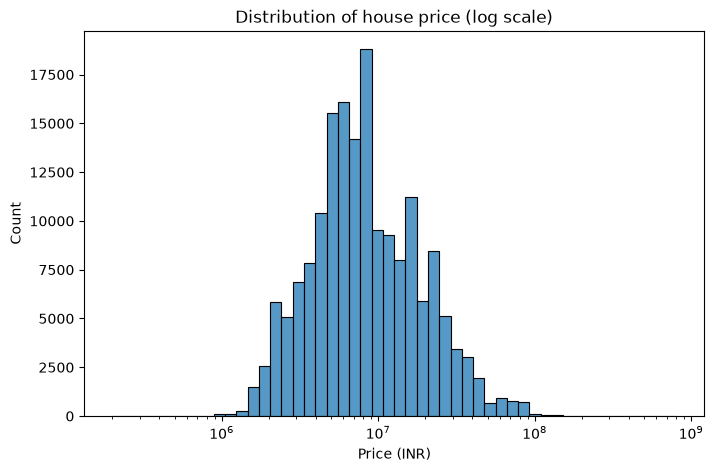

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df["price_clean"], log_scale=True, bins=50)
plt.title("Distribution of house price (log scale)")
plt.xlabel("Price (INR)")
plt.show()

**Takeaway:** Prices are heavily right-skewed on a linear scale. On a log scale the distribution is closer to log-normal — tree-based models handle this skew well.


### Plot 2 — Price vs. carpet area

Scatter of `price_clean` against `carpet_area_sqft`.


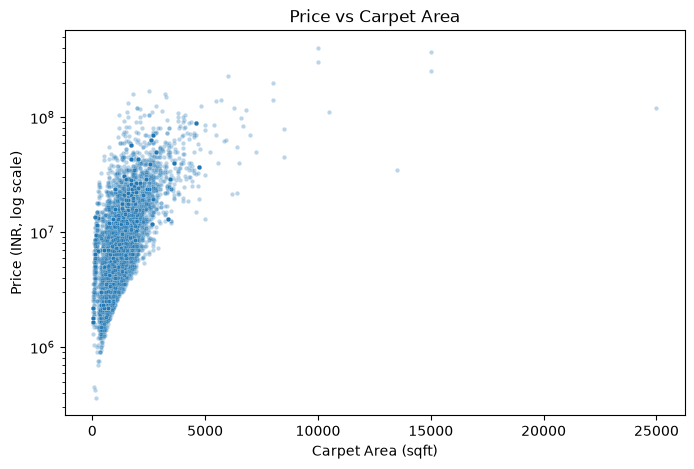

In [60]:
plt.figure(figsize=(8, 5))
sample = df.sample(min(20000, len(df)), random_state=42)
sns.scatterplot(data=sample, x="carpet_area_sqft", y="price_clean", alpha=0.3, s=10)
plt.yscale("log")
plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (INR, log scale)")
plt.show()

**Takeaway:** Clear positive area–price relationship, but wide variance at every size — location and amenities matter beyond area alone.


### Plot 3 — Average price by top-15 locations

Bar chart of mean `price_clean` for the most common locations.


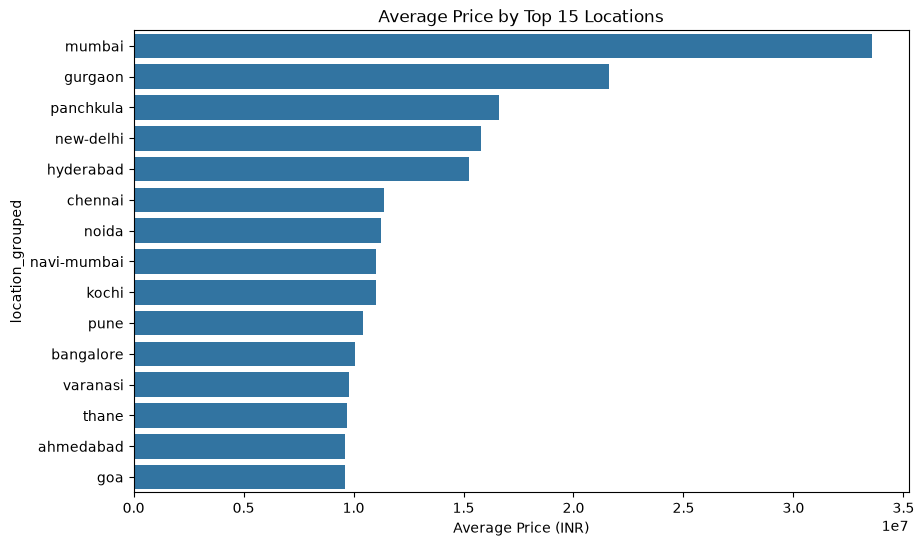

In [61]:
top15 = df.groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=top15.values, y=top15.index, orient="h")
plt.title("Average Price by Top 15 Locations")
plt.xlabel("Average Price (INR)")
plt.show()

**Takeaway:** Average price varies substantially by location — `location_grouped` should be a strong predictor.


### Plot 4 — Price by furnishing and bathrooms

Side-by-side box plots: price vs. `Furnishing` and vs. `bathroom` count.


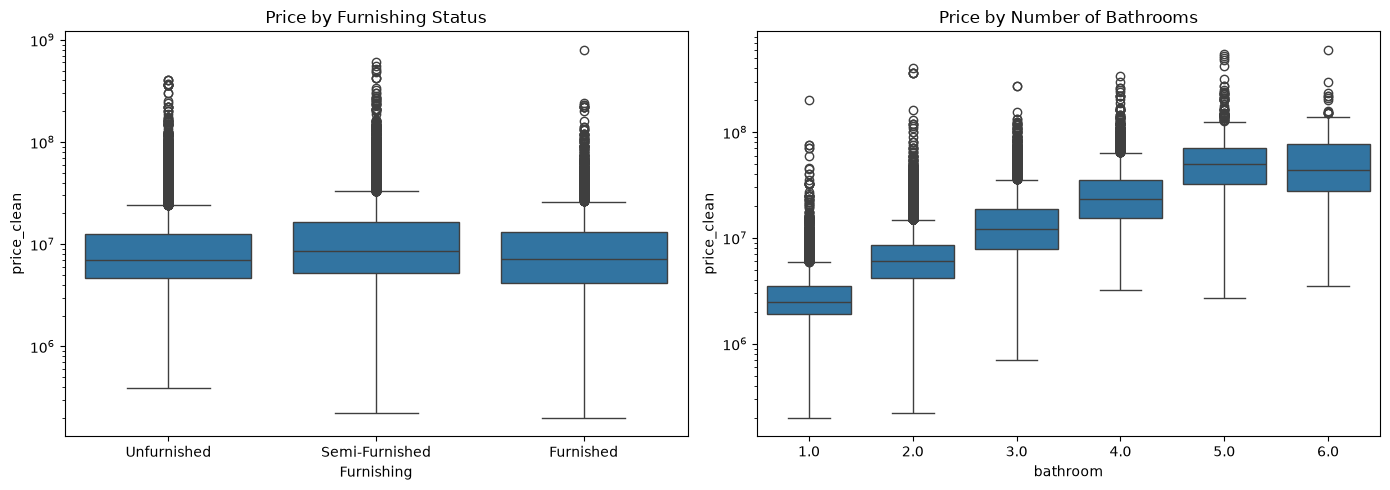

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Furnishing", y="price_clean", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by Furnishing Status")

bathroom_sample = df[df["bathroom"] <= 6]
sns.boxplot(data=bathroom_sample, x="bathroom", y="price_clean", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by Number of Bathrooms")

plt.tight_layout()
plt.show()

**Takeaway:** Fully furnished listings trend higher; price rises with bathroom count — both support including `Furnishing` and `bathroom` as features.


## 2.4 — Build scikit-learn Pipeline & Train

**Features used**

| Type | Columns |
|------|---------|
| Numeric | `carpet_area_sqft`, `floor_num`, `bathroom`, `balcony` |
| Categorical | `location_grouped`, `Furnishing`, `Transaction`, `Ownership`, `facing` |




In [63]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

NUMERIC_FEATURES = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
CATEGORICAL_FEATURES = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "price_clean"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, NUMERIC_FEATURES),
    ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
])

In [64]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=200, max_depth=20, random_state=42, n_jobs=-1
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

fitted_pipelines = {}
results = []

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,model,MAE,RMSE,R2
0,RandomForestRegressor,1.114024e+06,5.306273e+06,0.849210
1,GradientBoostingRegressor,2.613991e+06,6.134626e+06,0.798456
2,LinearRegression,4.521805e+06,8.407485e+06,0.621448


## 2.5 — Evaluation

Compare models on the held-out test set (MAE, RMSE, R²). **Random Forest** typically wins here: price depends on non-linear interactions between location, area, and amenities that a linear model cannot capture.

The cell below plots predicted vs. actual price (log scale) for the best model and prints the comparison table.



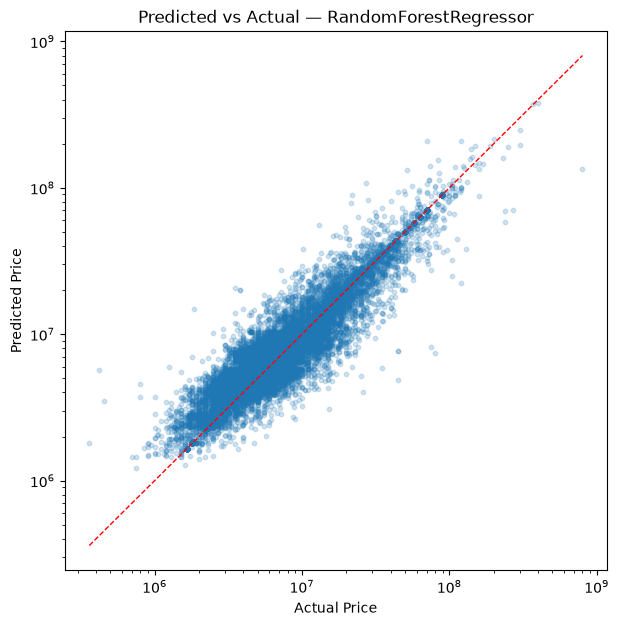

Winning model: RandomForestRegressor


,model,MAE,RMSE,R2
0,RandomForestRegressor,1.114024e+06,5.306273e+06,0.849210
1,GradientBoostingRegressor,2.613991e+06,6.134626e+06,0.798456
2,LinearRegression,4.521805e+06,8.407485e+06,0.621448


In [65]:
best_model_name = results_df.iloc[0]["model"]
best_pipeline = fitted_pipelines[best_model_name]
preds_best = best_pipeline.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds_best, alpha=0.2, s=10)
lims = [max(y_test.min(), 1), max(y_test.max(), preds_best.max())]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.show()

print(f"Winning model: {best_model_name}")
results_df

### Bonus — 5-fold cross-validation

Run 5-fold CV on the winning model to check that test-set R² is stable across data splits.



In [66]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    Pipeline([("preprocessor", preprocessor), ("model", models[best_model_name])]),
    X, y, cv=kf, scoring="r2", n_jobs=-1,
)
print("5-fold CV R2 scores:", np.round(cv_scores, 4))
print(f"Mean R2: {cv_scores.mean():.4f}  (+/- {cv_scores.std():.4f})")

5-fold CV R2 scores: [0.8521 0.9121 0.9062 0.8645 0.8654]
Mean R2: 0.8801  (+/- 0.0243)


## 2.6 — Export

Save artifacts for the web app:

- **`house_price.pkl`** — fitted preprocessing + model pipeline
- **`locations.json`** — list of allowed `location_grouped` values for the UI

After running, copy `house_price.pkl` to `backend/models/` and `locations.json` to the frontend (or serve from the backend).



In [67]:
import joblib
import json
import os

# compress=3 shrinks the pickle substantially (usually 3-5x) with no accuracy cost —
# this is what keeps house_price.pkl small enough to commit to the repo.
joblib.dump(best_pipeline, "house_price.pkl", compress=3)

size_mb = os.path.getsize("house_price.pkl") / (1024 * 1024)
print(f"house_price.pkl size: {size_mb:.1f} MB")
if size_mb > 50:
    print("⚠️  Still over ~50MB — reduce n_estimators/max_depth on the Random Forest, "
          "or track this file with Git LFS instead of committing it directly.")

# Sanity check: reload from disk and confirm identical predictions
reloaded = joblib.load("house_price.pkl")
sample_row = X_test.iloc[[0]]
assert np.isclose(reloaded.predict(sample_row)[0], best_pipeline.predict(sample_row)[0])
print("Sanity check passed: reloaded model produces an identical prediction.")

allowed_locations = sorted(df["location_grouped"].unique().tolist())
with open("locations.json", "w") as f:
    json.dump(allowed_locations, f, indent=2)
print(f"Exported {len(allowed_locations)} allowed locations to locations.json")

house_price.pkl size: 52.6 MB
⚠️  Still over ~50MB — reduce n_estimators/max_depth on the Random Forest, or track this file with Git LFS instead of committing it directly.
Sanity check passed: reloaded model produces an identical prediction.
Exported 51 allowed locations to locations.json


---

## Appendix — Optional experiment: log-transforming the target

This is a **self-contained experiment**, kept deliberately isolated from the main pipeline above. It uses its own suffixed variable names (`_exp`) and never touches `df`, `X`, `y`, `preprocessor`, `models`, `fitted_pipelines`, `results_df`, or `best_pipeline` — so whether this cell succeeds, fails, or is skipped entirely has **zero effect** on the rest of the notebook (EDA, training, evaluation, and the exported `house_price.pkl` / `locations.json` above are already final).

**Idea tested:** train on `log1p(price_clean)` instead of raw price, since the target is heavily right-skewed (see Plot 1), then invert with `expm1` before scoring.

**Result:** it doesn't help here, and actively wrecks `LinearRegression` (R² goes hugely negative). The reason: `expm1` is a fast-exploding function — a small, ordinary-looking error in log-space (which a weak linear fit produces plenty of) turns into a massive error once exponentiated back to rupees, and a handful of those blow up the RMSE/R² completely. Tree-based models are far less affected since they're already robust to skew (as seen in the main results), so the log transform buys little there either. **Conclusion: the main pipeline correctly trains on raw `price_clean`, not the log-transformed target.**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split as train_test_split_exp
from sklearn.metrics import mean_absolute_error as mae_exp, mean_squared_error as mse_exp, r2_score as r2_exp

X_exp = df[FEATURES]
y_log_exp = np.log1p(df[TARGET])

X_train_exp, X_test_exp, y_train_log_exp, y_test_log_exp = train_test_split_exp(
    X_exp, y_log_exp, test_size=0.2, random_state=42
)

log_experiment_results = []

for name, model in models.items():
    pipe_exp = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe_exp.fit(X_train_exp, y_train_log_exp)

    preds_log_exp = pipe_exp.predict(X_test_exp)
    preds_real_exp = np.expm1(preds_log_exp)
    y_test_real_exp = np.expm1(y_test_log_exp)

    log_experiment_results.append({
        "model": name,
        "MAE": mae_exp(y_test_real_exp, preds_real_exp),
        "RMSE": np.sqrt(mse_exp(y_test_real_exp, preds_real_exp)),
        "R2": r2_exp(y_test_real_exp, preds_real_exp),
    })

log_results_df = pd.DataFrame(log_experiment_results).sort_values("R2", ascending=False).reset_index(drop=True)
print("Main pipeline (raw target) results, for comparison:")
display(results_df)
print("\nLog-transformed-target experiment results:")
display(log_results_df)